In [1]:
from vnstock import *

**Vui lòng chuyển đổi sang Vnstock3** thế hệ mới (3.1.0) với câu lệnh: `pip install vnstock3 --upgrade`.
**Từ 1/1/2025, vnstock3 sẽ được cài đặt khi sử dụng cú pháp** `pip install vnstock` **thay cho Vnstock Legacy** hiện tại.
Xem chi tiết [chuyển đổi sang vnstock3](https://vnstocks.com/docs/tai-lieu/migration-chuyen-doi-sang-vnstock3).
Phiên bản **Vnstock Legacy (0.2.9.2.3)** bạn đang sử dụng **sẽ không được nâng cấp thêm.**
Từ 7/10/2024 Vnstock giới thiệu nhóm Facebook Cộng đồng Vnstock, tham gia thảo luận tại đây: https://www.facebook.com/groups/vnstock.official

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
import os
import random

In [3]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.layers import LSTM, Flatten, Dense, Masking, GRU
from tensorflow.keras.models import Sequential
from scikeras.wrappers import KerasRegressor
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
seed_value = 32  # Bạn có thể thay đổi seed theo ý muốn

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [6]:
start_date='2015-01-01'
end_date='2024-06-30'
df=stock_historical_data('HPG',start_date,end_date)
#df=pd.read_csv('HPG.csv',index_col=0)


In [7]:
#df.to_csv("HPG.csv")

In [8]:
df.columns=['time','close','open','high','low','volume','%']

In [9]:
df

,time,close,open,high,low,volume,%
0,2015-01-05,4160,4250,4130,4160,207020,HPG
1,2015-01-06,4080,4200,4080,4200,260380,HPG
2,2015-01-07,4200,4250,4160,4160,232770,HPG
3,2015-01-08,4160,4200,4130,4160,107380,HPG
4,2015-01-09,4160,4250,4130,4250,409230,HPG
...,...,...,...,...,...,...,...
2363,2024-06-24,29000,29100,28250,28700,37846100,HPG
2364,2024-06-25,28600,29050,28500,28700,16655000,HPG
2365,2024-06-26,28750,29200,28600,28900,19746800,HPG
2366,2024-06-27,29000,29050,28700,28850,10080500,HPG


In [10]:
df.set_index('time',inplace=True)
#Nếu dùng cho cổ phiếu thì dùng:
df.index=pd.to_datetime(df.index,format='%Y-%m-%d')
#Nếu dùng cho VNINDEX thì dùng
#df.index=pd.to_datetime(df.index,format='%d/%m/%Y')
df=df.sort_values('time')

In [11]:
pos_df=df.reset_index()

In [12]:
index_pos=pos_df[pos_df['time']=='2022-12-30'].index[0]

In [13]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [14]:
df['scaled_close']=scaler.fit_transform(df[['close']])

In [15]:
# Lấy giá đóng cửa
#Cho giá cổ phiếu
#train_data = df[['close']].iloc[:'2022-12-31'].values
#test_data = df[['close']].iloc['2023-01-01':'2023-12-31'].values
#Cho VNINDEX
train_data = df[['scaled_close']].iloc[:index_pos].values
test_data = df[['scaled_close']].iloc[index_pos:].values

# Tạo tập dữ liệu cho mô hình LSTM
def create_multistep_dataset(data, time_step, predict_step):
    X, y = [], []
    for i in range(time_step, len(data) - predict_step + 1):
        X.append(data[i-time_step:i, 0])  # Lấy 50 ngày trước đó làm đầu vào
        y.append(data[i:i+predict_step, 0])  # Lấy 5 ngày tiếp theo làm đầu ra
    return np.array(X), np.array(y)

time_step = 20
predict_step = 1
X_train, y_train = create_multistep_dataset(train_data, time_step, predict_step)
X_test, y_test = create_multistep_dataset(test_data, time_step, predict_step)

# Reshape dữ liệu cho LSTM [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [16]:
model_mix = Sequential([
    LSTM(units=256, return_sequences=True, input_shape=(time_step, 1)),  # LSTM layer đầu tiên
    GRU(units=256, return_sequences=False),
    Dense(units=256),
    Dense(units=predict_step)
])
# Compile mô hình
model_mix.compile(optimizer='adam', loss='mean_absolute_error')

# Huấn luyện mô hình
model_mix.fit(X_train, y_train, batch_size=32, epochs=100,shuffle=True)


Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0853
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0164
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0134
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - loss: 0.0120
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - loss: 0.0135
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0139
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0092
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0107
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0127
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - loss: 0.0088
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0104
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0115
Epoch 13/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0102
Epoch 14/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0116
Epoch 15/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s

In [17]:
# Dự đoán giá
yhat_train_mix = model_mix.predict(X_train)
yhat_test_mix = model_mix.predict(X_test)

# Đảo ngược chuẩn hóa
yhat_train_mix = scaler.inverse_transform(yhat_train_mix)
yhat_test_mix = scaler.inverse_transform(yhat_test_mix)

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [18]:
y_train_plot=scaler.inverse_transform(y_train)
y_test_plot=scaler.inverse_transform(y_test)

In [19]:
MSE_train=[mean_squared_error(y_train_plot,yhat_train_mix)]
RMSE_train=[root_mean_squared_error(y_train_plot,yhat_train_mix)]
MAE_train=[mean_absolute_error(y_train_plot,yhat_train_mix)]
R2_train=[r2_score(y_train_plot,yhat_train_mix)]
error_train_table=pd.DataFrame({'R2':R2_train,
                                'MSE':MSE_train,
                                'RMSE':RMSE_train,
                               'MAE':MAE_train})
error_train_table.index=['HPG']

In [20]:
MSE_test=[mean_squared_error(y_test_plot,yhat_test_mix)]
RMSE_test=[root_mean_squared_error(y_test_plot,yhat_test_mix)]
MAE_test=[mean_absolute_error(y_test_plot,yhat_test_mix)]
R2_test=[r2_score(y_test_plot,yhat_test_mix)]
error_test_table=pd.DataFrame({'R2':R2_test,
                                'MSE':MSE_test,
                                'RMSE':RMSE_test,
                               'MAE':MAE_test})
error_test_table.index=['HPG']

In [21]:
error_train_table.round(6)

,R2,MSE,RMSE,MAE
HPG,0.998065,175116.659243,418.469425,254.625792


In [22]:
error_test_table.round(6)

,R2,MSE,RMSE,MAE
HPG,0.978344,231213.852869,480.847016,373.977824


In [23]:
y_train_draw=y_train_plot.reshape(y_train_plot.shape[0],)
yhat_train_mix_draw=yhat_train_mix.reshape(yhat_train_mix.shape[0],)

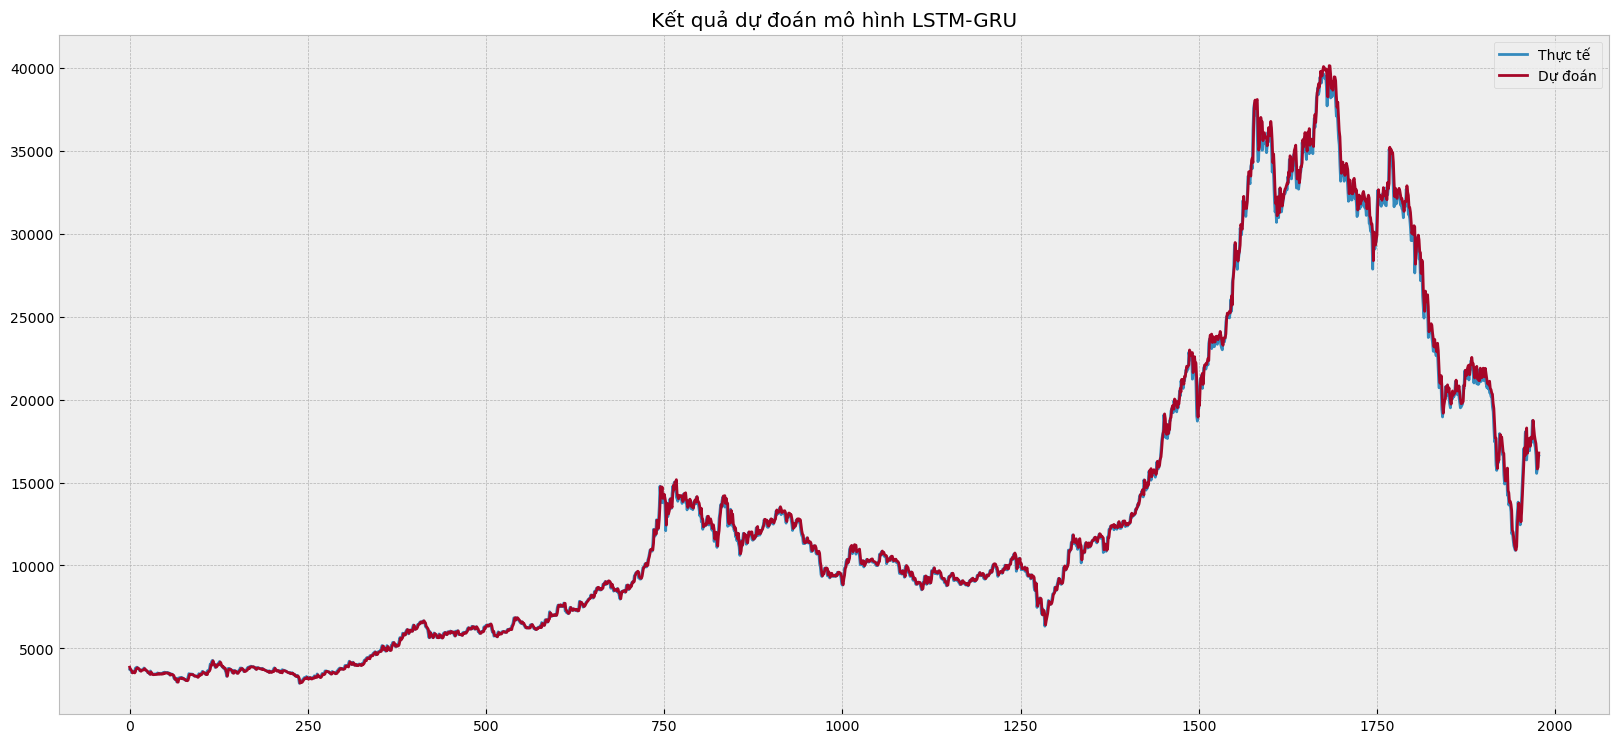

In [24]:
with plt.style.context('bmh'):
    plt.figure(figsize=[20,30])
    plt.subplot(3,1,1)
    plt.title('Kết quả dự đoán mô hình LSTM-GRU')
    plt.plot(y_train_draw,label='Thực tế')
    plt.plot(yhat_train_mix_draw,label='Dự đoán')
    plt.legend()
    plt.show()

In [25]:
y_test_draw=y_test_plot.reshape(y_test_plot.shape[0],)
yhat_test_mix_draw=yhat_test_mix.reshape(yhat_test_mix.shape[0],)

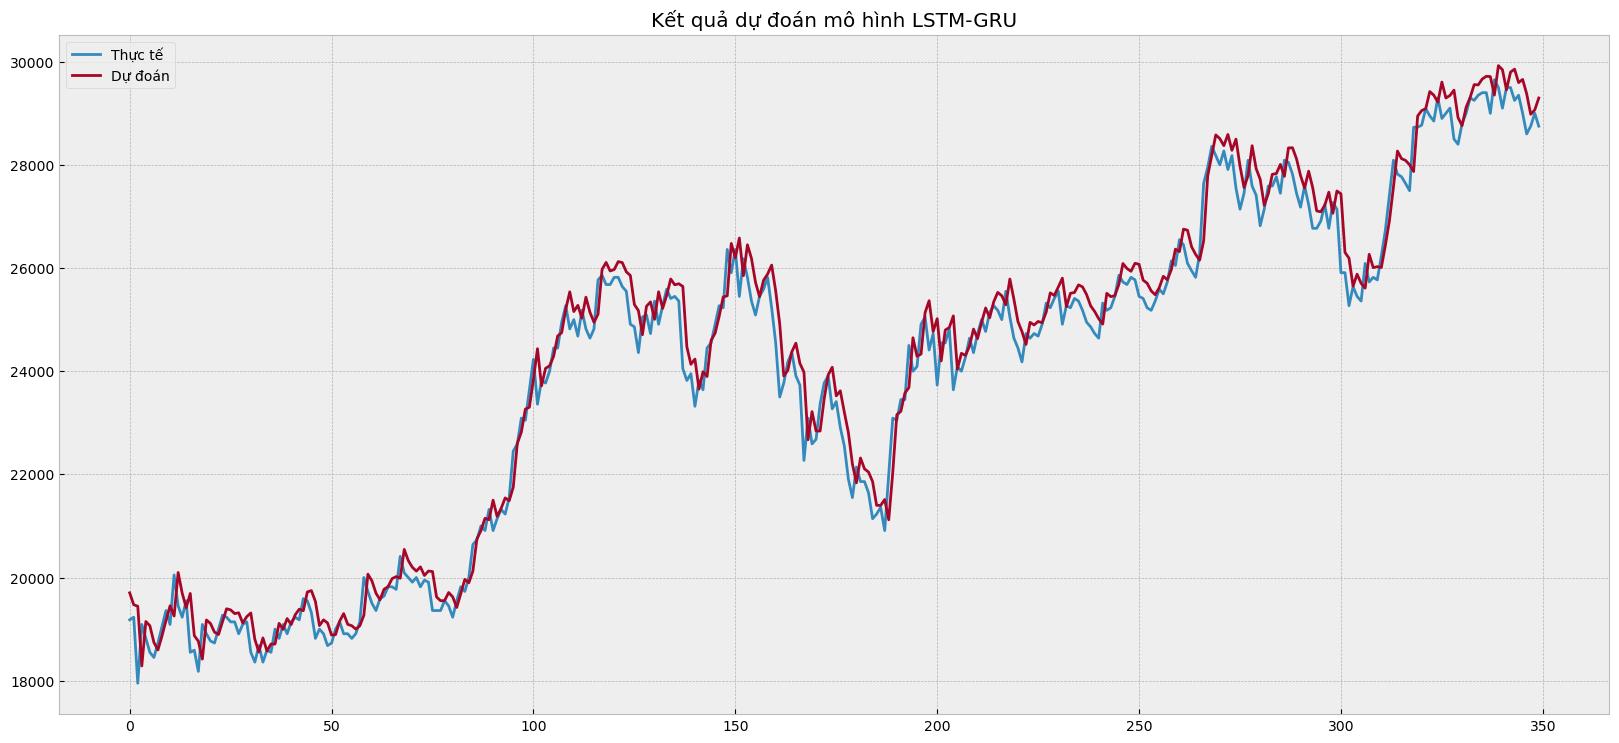

In [26]:
with plt.style.context('bmh'):
    plt.figure(figsize=[20,30])
    plt.subplot(3,1,1)
    plt.title('Kết quả dự đoán mô hình LSTM-GRU')
    plt.plot(y_test_draw,label='Thực tế')
    plt.plot(yhat_test_mix_draw,label='Dự đoán')
    plt.legend()
    plt.show()
    